In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [28]:
fund_master = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\01_fund_master.csv")
nav_history = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\02_nav_history.csv")
aum = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\03_aum_by_fund_house.csv")
sip = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\05_category_inflows.csv")
folio = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\06_industry_folio_count.csv")
performance = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\07_scheme_performance.csv")
transactions = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\08_investor_transactions.csv")
holdings = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\09_portfolio_holdings.csv")
benchmark = pd.read_csv(r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\10_benchmark_indices.csv")

In [29]:
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category_inflows": category_inflows,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

fund_master: (40, 15)
nav_history: (46000, 3)
aum: (90, 5)
sip: (48, 6)
category_inflows: (144, 3)
folio: (21, 6)
performance: (40, 19)
transactions: (32778, 13)
holdings: (322, 8)
benchmark: (8050, 3)


# Exploratory Data Analysis (EDA)

This notebook explores the mutual fund ecosystem using:

- Fund master data
- NAV history
- AUM trends
- SIP inflows
- Category inflows
- Investor transactions
- Portfolio holdings
- Benchmark performance

Objective:
- Understand industry trends
- Identify top-performing funds
- Analyze investor behaviour
- Study portfolio diversification

In [30]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


fund_master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

nav_history
amfi_code    0
date         0
nav          0
dtype: int64

aum
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

sip
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

category_inflows
month               0
category            0
net_inflow_crore    0
dtype: int64

folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_foli

In [31]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.dtypes)


fund_master
amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object

nav_history
amfi_code      int64
date          object
nav          float64
dtype: object

aum
date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

sip
month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

category_inflows
month                obje

In [32]:
performance.describe(include="all")

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
count,40.000000,40,40,40,40,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000,40
unique,NaN,40,10,12,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,NaN,1,5,14,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
mean,120247.000000,NaN,NaN,NaN,NaN,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000,NaN
std,14534.998667,NaN,NaN,NaN,NaN,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484,NaN
min,100016.000000,NaN,NaN,NaN,NaN,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000,NaN
25%,118632.750000,NaN,NaN,NaN,NaN,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000,NaN
50%,119551.500000,NaN,NaN,NaN,NaN,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000,NaN
75%,120842.250000,NaN,NaN,NaN,NaN,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000,NaN


In [33]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

## Fund Category Distribution

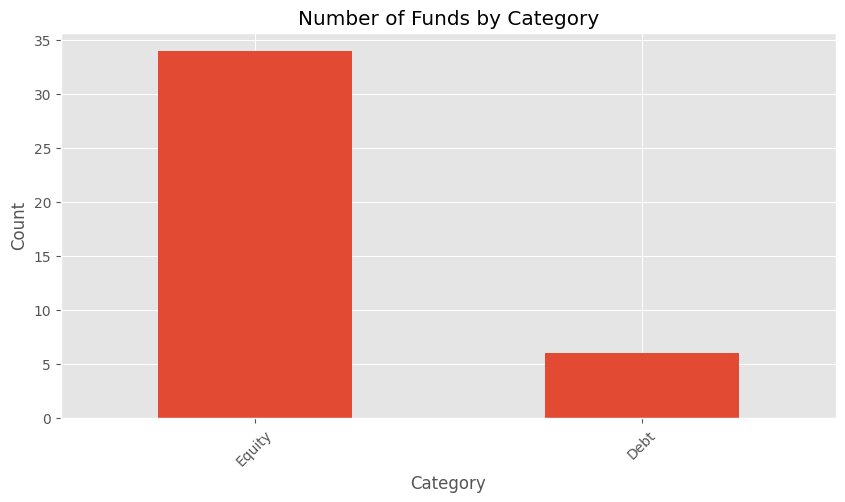

In [34]:
plt.figure(figsize=(10,5))

fund_master["category"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Funds by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

## Risk Category Distribution

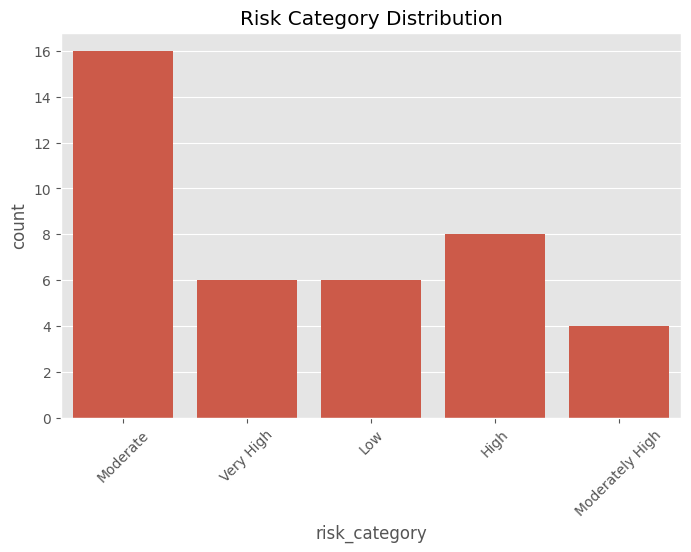

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category"
)

plt.title("Risk Category Distribution")
plt.xticks(rotation=45)

plt.show()

## Top Fund Houses

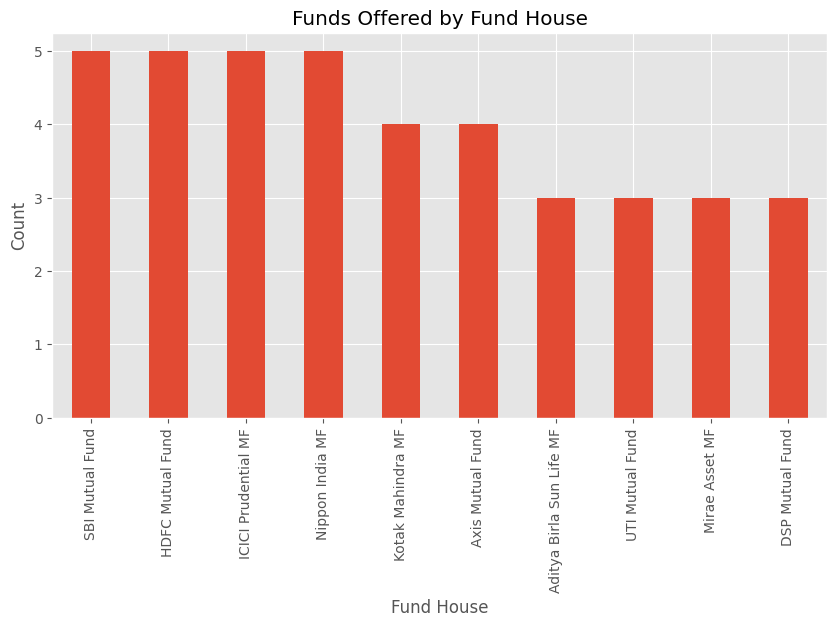

In [36]:
plt.figure(figsize=(10,5))

fund_master["fund_house"].value_counts().plot(
    kind="bar"
)

plt.title("Funds Offered by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

## Expense Ratio Analysis

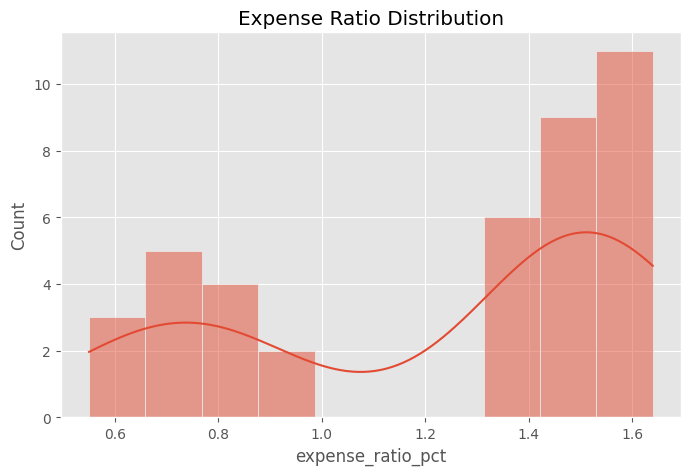

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    fund_master["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

## Exit Load Distribution

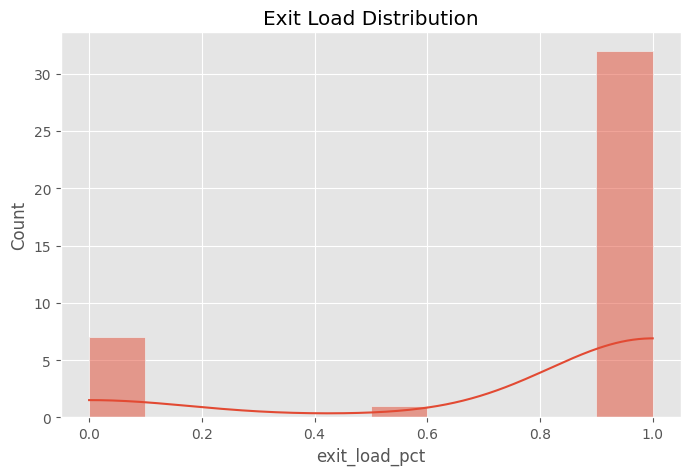

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    fund_master["exit_load_pct"],
    bins=10,
    kde=True
)

plt.title("Exit Load Distribution")

plt.show()

In [39]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

## Top 10 Funds by 5-Year Return

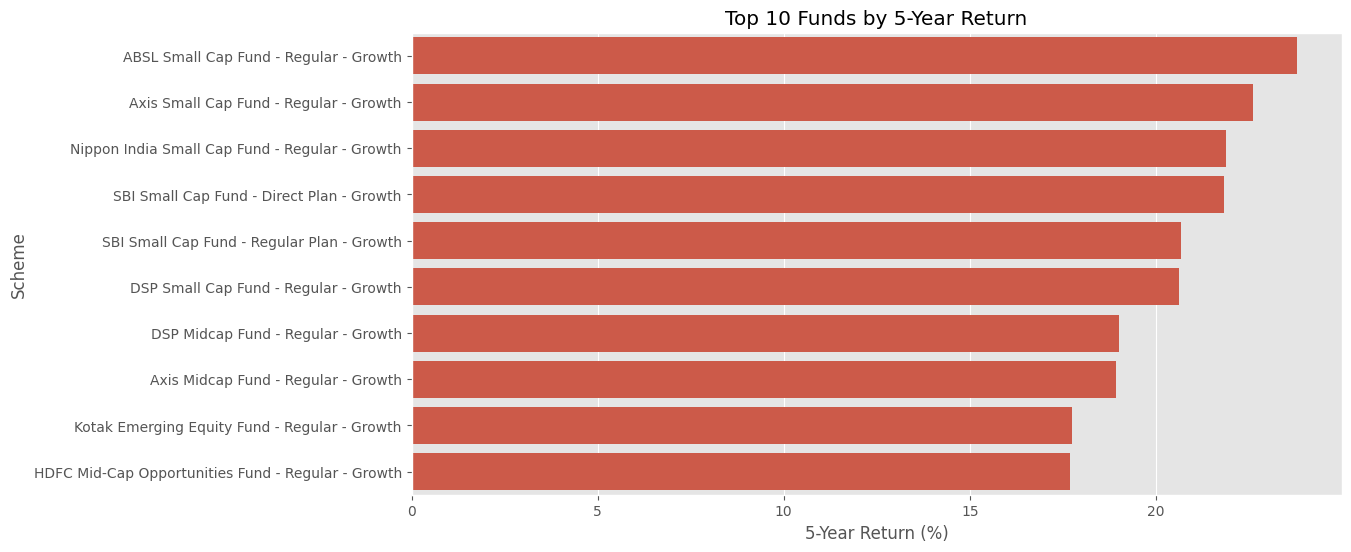

In [40]:
top_5yr = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_5yr,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")

plt.show()

## Distribution of Returns

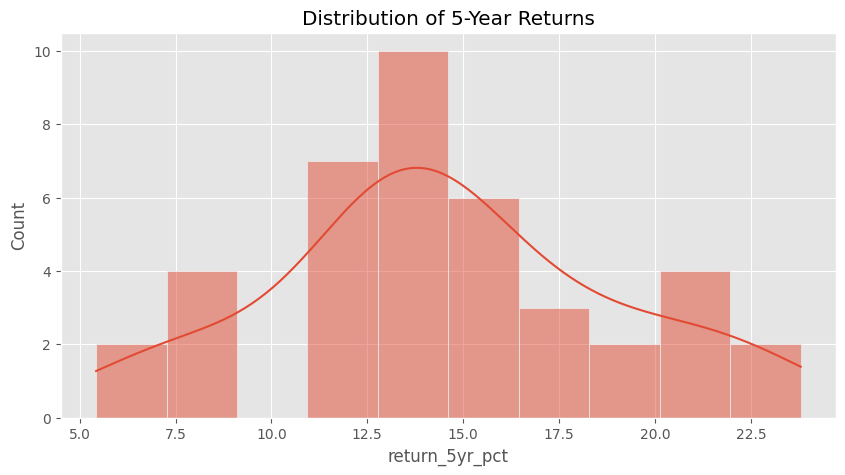

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance["return_5yr_pct"],
    bins=10,
    kde=True
)

plt.title("Distribution of 5-Year Returns")

plt.show()

## 1-Year vs 3-Year Returns

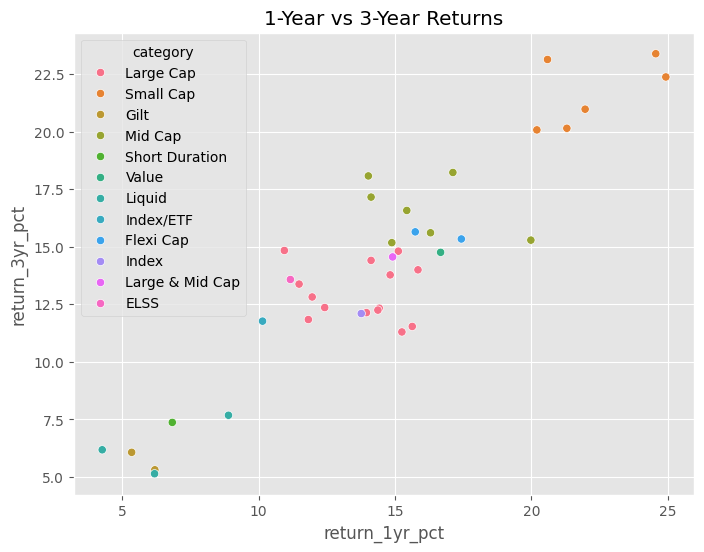

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=performance,
    x="return_1yr_pct",
    y="return_3yr_pct",
    hue="category"
)

plt.title("1-Year vs 3-Year Returns")

plt.show()

## Fund Performance vs Benchmark

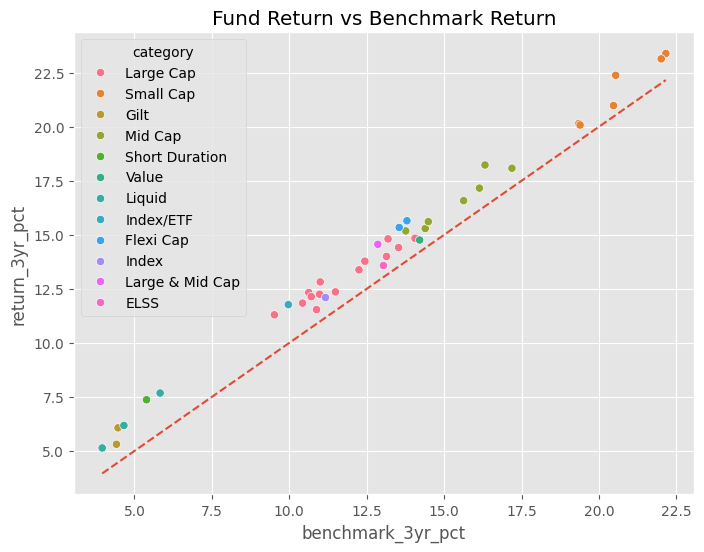

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=performance,
    x="benchmark_3yr_pct",
    y="return_3yr_pct",
    hue="category"
)

plt.plot(
    [performance["benchmark_3yr_pct"].min(),
     performance["benchmark_3yr_pct"].max()],
    [performance["benchmark_3yr_pct"].min(),
     performance["benchmark_3yr_pct"].max()],
    linestyle="--"
)

plt.title("Fund Return vs Benchmark Return")

plt.show()

## Sharpe Ratio Comparison

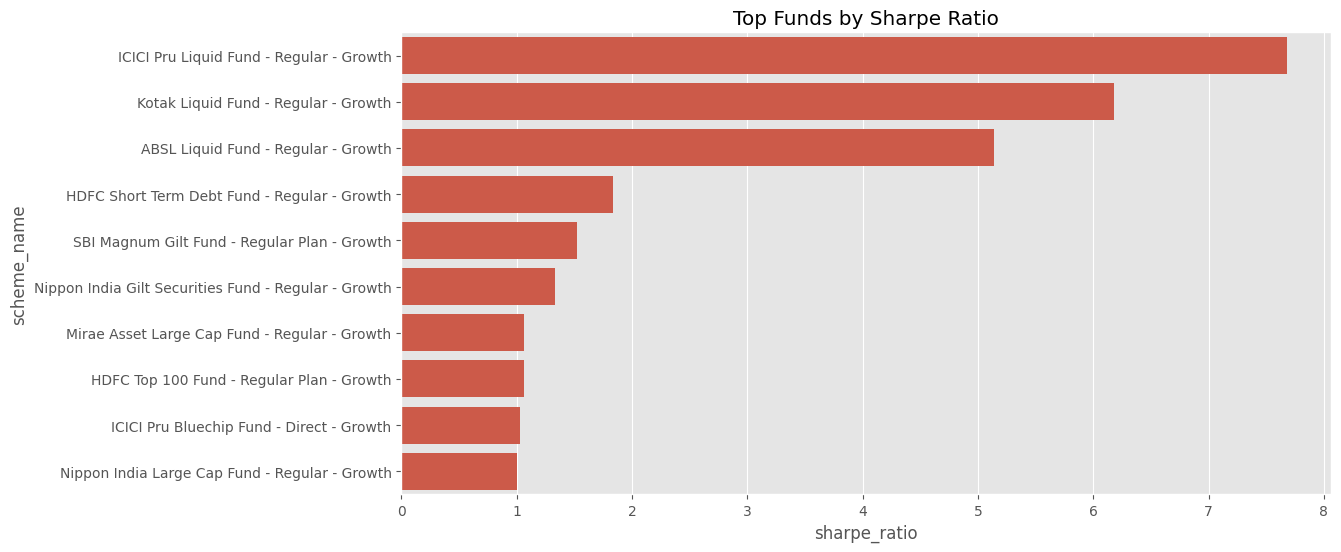

In [44]:
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top Funds by Sharpe Ratio")

plt.show()

## Risk vs Return

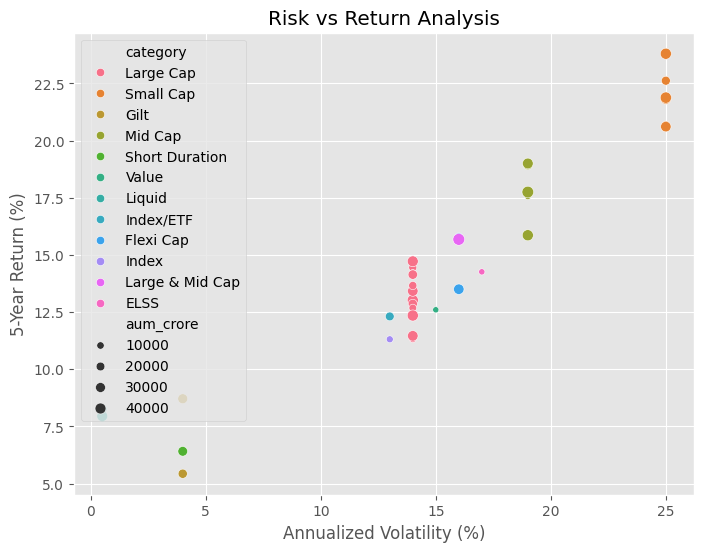

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    hue="category",
    size="aum_crore"
)

plt.title("Risk vs Return Analysis")

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("5-Year Return (%)")

plt.show()

# Key Insights

1. Large Cap funds dominate the sample dataset.
2. Several funds significantly outperform their benchmark.
3. Higher Sharpe ratio funds provide better risk-adjusted returns.
4. Return and volatility show a positive relationship.
5. A few schemes consistently rank among top performers across multiple metrics.

# NAV Trend Analysis

In [46]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [47]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

## NAV Trend of Top Funds

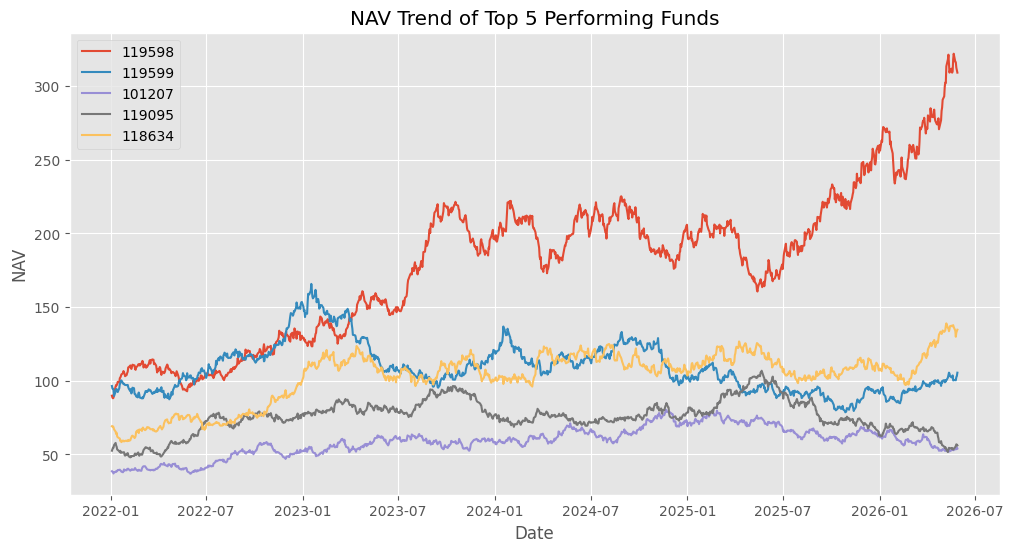

In [48]:
top_funds = performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(5)

top_codes = top_funds["amfi_code"]

top_nav = nav_history[
    nav_history["amfi_code"].isin(top_codes)
]

plt.figure(figsize=(12,6))

for code in top_codes:
    fund_data = top_nav[top_nav["amfi_code"] == code]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(code)
    )

plt.title("NAV Trend of Top 5 Performing Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

## NAV Growth Analysis

In [49]:
nav_growth = (
    nav_history.groupby("amfi_code")["nav"]
    .agg(["first", "last"])
)

nav_growth["growth_pct"] = (
    (nav_growth["last"] - nav_growth["first"])
    / nav_growth["first"]
) * 100

nav_growth.sort_values(
    "growth_pct",
    ascending=False
).head(10)

,first,last,growth_pct
amfi_code,,,
120505,135.8720,473.7640,248.684056
119598,89.8738,309.2050,244.043537
149324,81.6814,279.7511,242.490579
148569,28.8620,97.7435,238.658097
148567,70.2514,230.2708,227.781083
120843,49.9131,163.2397,227.047809
100033,107.3758,342.0072,218.514228
149323,78.4622,245.3651,212.717589
119094,68.3023,203.8581,198.464473


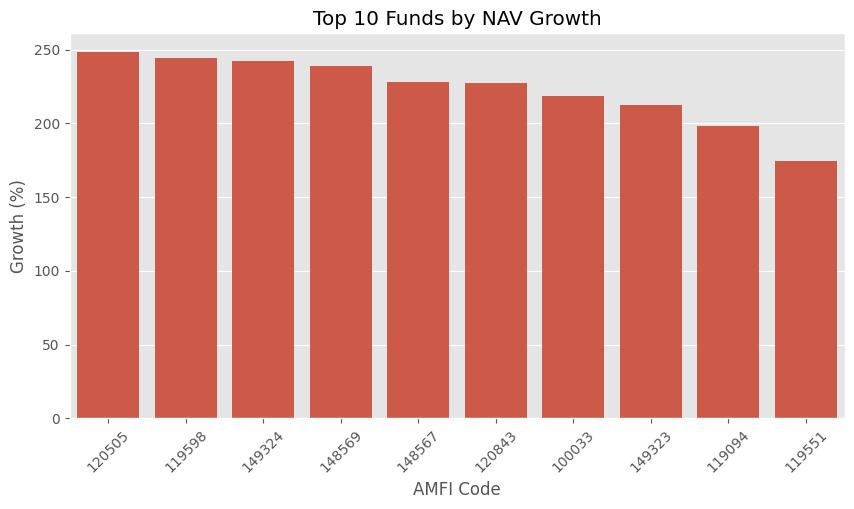

In [50]:
top_growth = (
    nav_growth.sort_values(
        "growth_pct",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_growth.index.astype(str),
    y=top_growth["growth_pct"]
)

plt.title("Top 10 Funds by NAV Growth")
plt.xlabel("AMFI Code")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)

plt.show()

# Final EDA Insights

1. Small Cap funds delivered the highest long-term returns.

2. Most schemes outperformed their benchmark over 3 years.

3. Higher risk categories generally generated higher returns.

4. Liquid and Debt funds exhibited superior risk-adjusted performance.

5. Expense ratios remained within reasonable industry ranges.

6. NAV trends indicate strong long-term wealth creation across equity funds.

7. Large Cap funds provide stability while Small Cap funds offer aggressive growth.

8. Sharpe Ratio analysis identifies several highly efficient funds.

9. Benchmark comparison confirms active fund managers added value.

10. Mutual fund performance strongly correlates with risk exposure.